# Modelo Fitzhug-Nagumo

Evaluacion de las funciones de disparo, modificacion de la funcion m y comparacion del modelo

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hh_equations import a_n, b_n, a_m, b_m, a_h, b_h

#plt.style.use('classic')  # Puedes probar otros estilos como 'ggplot' 'bmh', 'classic', etc.


In [2]:

# Constants for the method
Cm = 1                     # membrane capacitance uF/cm^2
dt = 0.01                  # delta time in ms
t = np.arange(0, 60, dt)   # time array in ms

I = 15  # external current applyed

ENa=50      # mv Na reversal potential 
EK=-77      # mv K reversal potential 
El=-54.4    # mv Leakage reversal potential 
gbarNa=120  # mS/cm^2 Na conductance 
gbarK=36    # mS/cm^2 K conductance 
gbarl=0.3   # mS/cm^2 Leakage conductance
V_rest = -60

n_inf = np.zeros(len(t))
m_inf = np.zeros(len(t))
h_inf = np.zeros(len(t))
Vfn = np.zeros(len(t))
Vfn[0] = np.array(V_rest)  # Valor inicial de la solucion

m_inf[0] = a_m(Vfn[0])/(a_m(Vfn[0])+b_m(Vfn[0]))    # Initial m-value
n_inf[0] = a_n(Vfn[0])/(a_n(Vfn[0])+b_n(Vfn[0]))    # Initial n-value
h_inf[0] = a_h(Vfn[0])/(a_h(Vfn[0])+b_h(Vfn[0]))    # Initial h-value


for i in range(0, len(t) - 1):

    # Euler method
    m_inf[i+1]= a_m(Vfn[i])/(a_m(Vfn[i])+b_m(Vfn[i]))   # first assumption
    n_inf[i+1]= n_inf[i]+dt*((a_n(Vfn[i])*(1-n_inf[i]))-(b_n(Vfn[i])*n_inf[i])) 
    h_inf[i+1]= 0.8-n_inf[i+1]
    
    gNafn = gbarNa*h_inf[i]*m_inf[i]**3
    gKfn  = gbarK*n_inf[i]**4
    glfn  = gbarl
    
    INa_fn = gNafn*(Vfn[i]-ENa)
    IK_fn  = gKfn*(Vfn[i]-EK)
    Il_fn  = glfn*(Vfn[i]-El)
    
    # Euler method to find the next voltage value
    Vfn[i+1]=Vfn[i]+(dt)*((1/Cm)*(I-(INa_fn+IK_fn+Il_fn)))


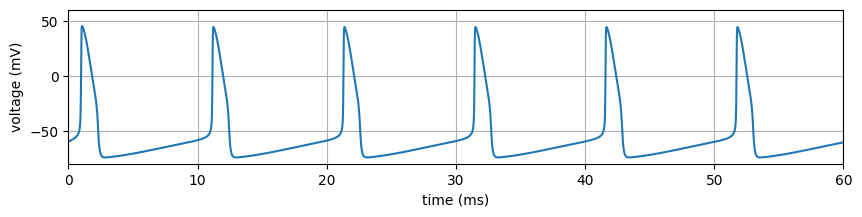

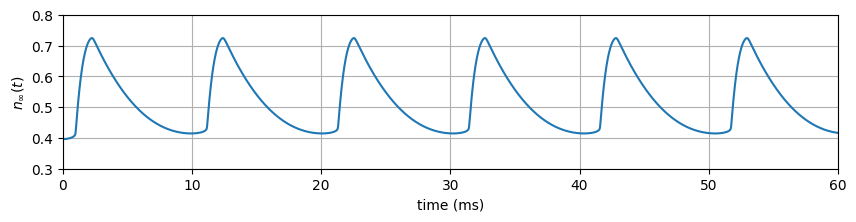

In [5]:
plt.figure(figsize=(10,2))
plt.plot(t, Vfn)
#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.xlim([0, 60])
plt.ylim([-80, 60])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/FHN_voltage.pdf", format="pdf", bbox_inches="tight")


# 
plt.figure(figsize=(10,2))
plt.plot(t, n_inf)

#plt.fill_between(t-40, V+80, color='skyblue', alpha=0.6)

# Configurar la leyenda y las etiquetas de los ejes
#plt.title("Torio")
#plt.legend(["$m$", "$m_\infty$"])
plt.xlabel('time (ms)')
plt.ylabel('$n_\infty(t)$')
plt.xlim([0, 60])
plt.ylim([0.3, 0.8])
plt.grid(True)

# Mostrar el gráfico
#plt.show()

plt.savefig("output/FHN_nparam.pdf", format="pdf", bbox_inches="tight")
